In [ ]:
!pip install kagglehub nltk wordcloud -q

import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import warnings
warnings.filterwarnings('ignore')

# Text processing
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
import kagglehub

# Downloading the dataset
path = kagglehub.dataset_download("yasserh/amazon-product-reviews-dataset")

print("Dataset downloaded to:", path)
print("Files in folder:", os.listdir(path))

100%|██████████| 708k/708k [00:00<00:00, 23.2MB/s]

Extracting files...
Dataset downloaded to: /root/.cache/kagglehub/datasets/yasserh/amazon-product-reviews-dataset/versions/1
Files in folder: ['7817_1.csv']


In [ ]:
# Find the CSV file
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print("CSV files found:", csv_files)

# Load the first CSV
df = pd.read_csv(os.path.join(path, csv_files[0]))

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)
df.head()

CSV files found: ['7817_1.csv']
Dataset loaded successfully!
Shape of dataset: (1597, 27)


,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I bought one of the first Paperwhites and have...,Love / Hate relationship,NaN,NaN,Dougal,NaN,NaN,205 grams
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I have to say upfront - I don't like coroporat...,I LOVE IT,NaN,NaN,Miljan David Tanic,NaN,NaN,205 grams


Columns: ['id', 'asins', 'brand', 'categories', 'colors', 'dateAdded', 'dateUpdated', 'dimension', 'ean', 'keys', 'manufacturer', 'manufacturerNumber', 'name', 'prices', 'reviews.date', 'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.userCity', 'reviews.userProvince', 'reviews.username', 'sizes', 'upc', 'weight']
Rating distribution:
reviews.rating
1.0     42
2.0     34
3.0    124
4.0    236
5.0    741
Name: count, dtype: int64


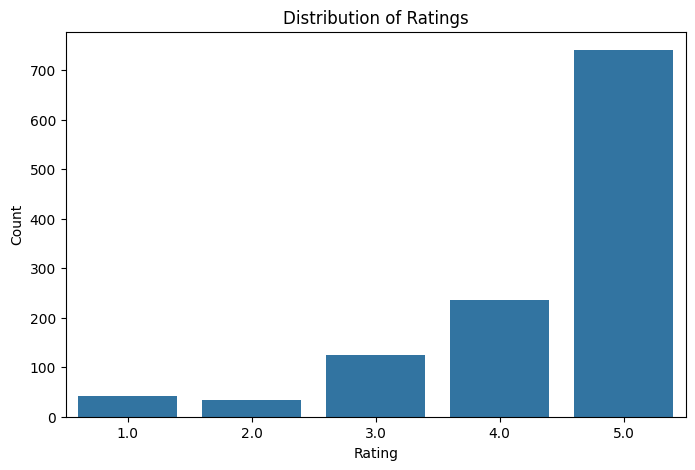

In [ ]:
print("Columns:", df.columns.tolist())
print("Rating distribution:")
print(df['reviews.rating'].value_counts().sort_index())

plt.figure(figsize=(8, 5))
sns.countplot(x='reviews.rating',  data=df)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [ ]:

# "reviews.text" column is text column we need
df["reviews.text"]

,reviews.text
0,I initially had trouble deciding between the p...
1,Allow me to preface this with a little history...
2,I am enjoying it so far. Great for reading. Ha...
3,I bought one of the first Paperwhites and have...
4,I have to say upfront - I don't like coroporat...
...,...
1592,This is not the same remote that I got for my ...
1593,I have had to change the batteries in this rem...
1594,"Remote did not activate, nor did it connect to..."
1595,It does the job but is super over priced. I fe...


In [ ]:
# Text cleaning function
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)      # Remove punctuation and numbers
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Apply cleaning
df['clean_review'] = df['reviews.text'].apply(clean_text)   # Change 'review_text' if your column name is different

# Create Sentiment Label (Binary: Positive vs Negative)
def get_sentiment(rating):
    if rating >= 4:
        return 1   # Positive
    else:
        return 0   # Negative (1,2,3)

df['sentiment'] = df['reviews.rating'].apply(get_sentiment)

print("Preprocessing Done!")
print("Sentiment Distribution:")
print(df['sentiment'].value_counts())
df[['reviews.text', 'clean_review', 'reviews.rating', 'sentiment']].head()

Preprocessing Done!
Sentiment Distribution:
sentiment
1    977
0    620
Name: count, dtype: int64


,reviews.text,clean_review,reviews.rating,sentiment
0,I initially had trouble deciding between the p...,initially trouble deciding paperwhite voyage r...,5.0,1
1,Allow me to preface this with a little history...,allow preface little history casual reader own...,5.0,1
2,I am enjoying it so far. Great for reading. Ha...,enjoying far great reading original fire since...,4.0,1
3,I bought one of the first Paperwhites and have...,bought one first paperwhites pleased constant ...,5.0,1
4,I have to say upfront - I don't like coroporat...,say upfront dont like coroporate hermetically ...,5.0,1


In [ ]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X = df['clean_review']
y = df['sentiment']

X_vec = vectorizer.fit_transform(X)

print("Shape of feature matrix:", X_vec.shape)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Shape of feature matrix: (1597, 5000)
Training samples: 1277
Testing samples: 320


In [ ]:
# ==================== FINAL MODEL EVALUATION ====================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

print("FINAL MODEL COMPARISON\n")

# 1. Best Logistic Regression (with class balancing)
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=== 1. Logistic Regression (Best) ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred_lr)*100, 2), "%")
print(classification_report(y_test, y_pred_lr))

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n=== 2. Random Forest ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred_rf)*100, 2), "%")
print(classification_report(y_test, y_pred_rf))

# 3. Linear SVC
svc = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)

print("\n=== 3. Linear SVC ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred_svc)*100, 2), "%")
print(classification_report(y_test, y_pred_svc))

print("\nModel Comparison Completed!")

FINAL MODEL COMPARISON

=== 1. Logistic Regression (Best) ===
Accuracy : 73.75 %
              precision    recall  f1-score   support

           0       0.61      0.81      0.69       118
           1       0.86      0.70      0.77       202

    accuracy                           0.74       320
   macro avg       0.73      0.75      0.73       320
weighted avg       0.77      0.74      0.74       320


=== 2. Random Forest ===
Accuracy : 73.44 %
              precision    recall  f1-score   support

           0       0.63      0.67      0.65       118
           1       0.80      0.77      0.79       202

    accuracy                           0.73       320
   macro avg       0.72      0.72      0.72       320
weighted avg       0.74      0.73      0.74       320


=== 3. Linear SVC ===
Accuracy : 72.19 %
              precision    recall  f1-score   support

           0       0.60      0.75      0.67       118
           1       0.83      0.70      0.76       202

    accuracy  

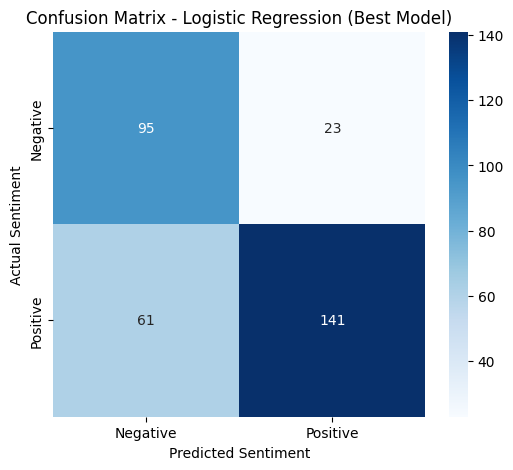

Confusion Matrix Interpretation:
True Negative  : 95
False Positive : 23
False Negative : 61
True Positive  : 141


In [ ]:
# ==================== CONFUSION MATRIX ====================

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Using the best model (Logistic Regression with balancing)
y_pred = lr.predict(X_test)        # 'lr' is your best model from previous cell

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.title('Confusion Matrix - Logistic Regression (Best Model)')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()

# Print interpretation
print("Confusion Matrix Interpretation:")
print(f"True Negative  : {cm[0][0]}")
print(f"False Positive : {cm[0][1]}")
print(f"False Negative : {cm[1][0]}")
print(f"True Positive  : {cm[1][1]}")